# Spatial Clustering: NYC Uber Pickups

Dataset: [`fivethirtyeight/uber-pickups-in-new-york-city`](https://www.kaggle.com/datasets/fivethirtyeight/uber-pickups-in-new-york-city),
April 2014 file. Only `Lat` / `Lon` are used. There is no ground truth, so only internal
metrics (silhouette, Davies-Bouldin) are reported.

Goal: discover urban transit hotspots and isolate outer-borough pickups as noise.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sc4020 import data, clustering, metrics, viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RESULTS_DIR = Path("..") / "results"

METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_points",
    "silhouette", "davies_bouldin",
]

## Load and filter

Pickups outside the NYC bounding box are dropped, then 15,000 points are sampled for speed
and clean plots.

In [2]:
ds = data.load_uber_pickups(n_samples=15000, random_state=42)
print(f"April 2014 file: {ds.extra['n_rows_raw']:,} rows -> {ds.extra['n_rows_in_nyc']:,} inside NYC "
      f"-> sampled X={ds.X.shape}")

April 2014 file: 564,516 rows -> 558,019 inside NYC -> sampled X=(15000, 2)


## Fit clustering models

* **DBSCAN:** ε = 0.35 km (350 m), `min_samples=30`, haversine metric with a BallTree index.
  It is fitted on coordinates in **radians**.
* **K-Means (k=5)** and **GMM (k=5)**: partitioning baselines, fitted on degrees.

In [3]:
models = clustering.uber_models(radius_km=0.35)
results = clustering.run_models(
    models, ds.X,
    inputs={name: ds.extra["coords_rad"] for name in models if "DBSCAN" in name},
)
for name, r in results.items():
    print(f"{name:26s} fit_seconds={r.fit_seconds:.3f}")

DBSCAN (Haversine ~350m)   fit_seconds=0.563
K-Means (k=5)              fit_seconds=1.444
GMM (k=5)                  fit_seconds=0.080


## Metrics

Silhouette is computed on a 3,000-point subsample to keep it fast.

In [4]:
results_df = metrics.build_results_table(
    ds.name, ds.X, results, silhouette_sample_size=3000
)
display(results_df[METRIC_COLS].round(4))
results_df.to_csv(RESULTS_DIR / "uber_pickups_results.csv", index=False)

,method,fit_seconds,n_clusters_found,noise_points,silhouette,davies_bouldin
0,DBSCAN (Haversine ~350m),0.5634,7,1798,0.2946,0.4601
1,K-Means (k=5),1.4439,5,0,0.4753,0.6851
2,GMM (k=5),0.0797,5,0,0.4474,0.8325


## Spatial visualization

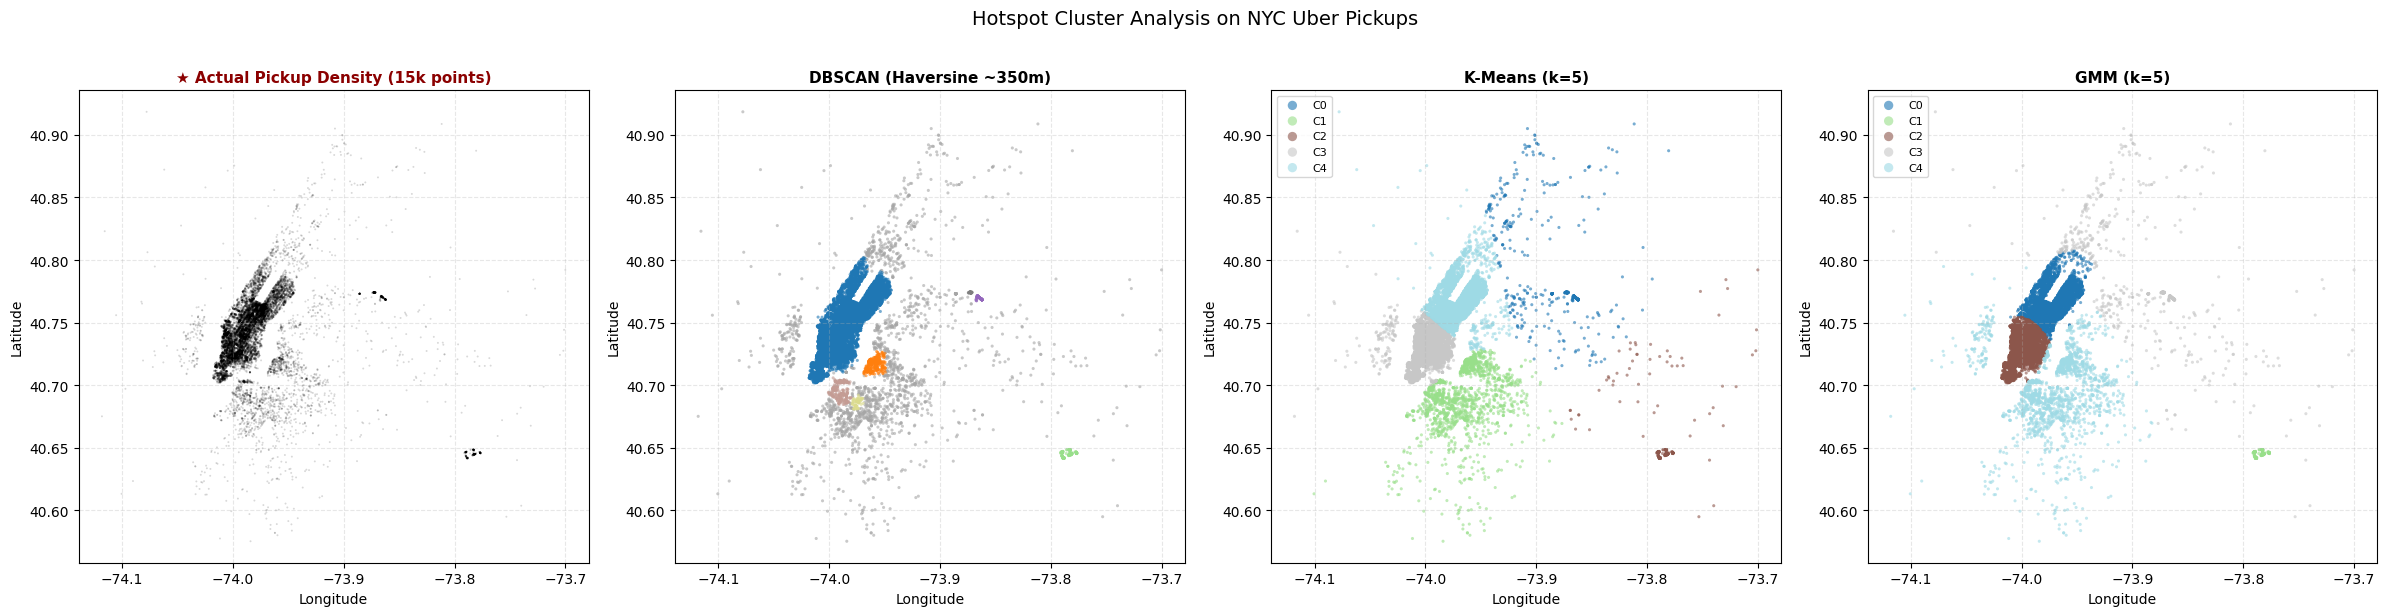

In [5]:
viz.plot_spatial_grid(
    ds.X, results,
    title="Hotspot Cluster Analysis on NYC Uber Pickups",
    reference_title="★ Actual Pickup Density (15k points)",
)
plt.show()

## Discussion

* **DBSCAN geometric alignment:** traces the elongated density corridors of Manhattan and
  isolates major hubs (JFK in the southeast, LaGuardia in the north) as distinct components.
* **Noise filtering:** dispersed pickups across Staten Island, deep Brooklyn and Queens fall
  into the noise label (`-1`) instead of skewing centroids.
* **Partitioning models (K-Means & GMM):** they must assign every point to a cluster, so
  isolated suburban trips get arbitrary radial boundaries and the continuous Manhattan
  corridor is cut into rigid convex cells.